### 1) Problem statement
- This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.


### 2) Data Collection
- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
- The data consists of 8 column and 1000 rows.

### 2.1 Import Data and Required Packages
####  Importing Pandas, Numpy, Matplotlib, Seaborn and Warnings Library.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

#### Import the CSV Data as Pandas DataFrame

In [3]:
df = pd.read_csv('data/stud.csv')

#### Show Top 5 Records

In [4]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
df.shape

(1000, 8)

### 2.2 Dataset information

- gender : sex of students  -> (Male/female)
- race/ethnicity : ethnicity of students -> (Group A, B,C, D,E)
- parental level of education : parents' final education ->(bachelor's degree,some college,master's degree,associate's degree,high school)
- lunch : having lunch before test (standard or free/reduced) 
- test preparation course : complete or not complete before test
- math score
- reading score
- writing score

### 3. Data Checks to perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

### 3.1 Check Missing values

In [6]:
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

#### There are no missing values in the data set

### 3.2 Check Duplicates

In [7]:
df.duplicated().sum()

np.int64(0)

#### There are no duplicate values in the dataset

### 3.3 Check data types

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


### 3.4 Checking the number of unique values of each column

In [9]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

### 3.5 Check statistics of data set

In [10]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#### Insight
- From above description of numerical data, all means are very close to each other - between 66 and 68.05;
- All standard deviations are also close - between 14.6 and 15.19;
- While there is a minimum score  0 for math, for writing minimum is much higher = 10 and for reading myet higher = 17

### 3.7 Exploring Data

In [13]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [11]:
print("Categories in 'gender' variable:      ", end = " ")
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable:      ", end = " ")
print(df['race_ethnicity'].unique())

print("Categories in 'parental_level_of_education' variable:      ", end = " ")
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable:      ", end = " ")
print(df['lunch'].unique())

print("Categories in 'test_preparation_course' variable:      ", end = " ")
print(df['test_preparation_course'].unique())

Categories in 'gender' variable:       <StringArray>
['female', 'male']
Length: 2, dtype: str
Categories in 'race_ethnicity' variable:       <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Categories in 'parental_level_of_education' variable:       <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categories in 'lunch' variable:       <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in 'test_preparation_course' variable:       <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [12]:
#define numerical and categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != "str"]
categorical_features = [feature for feature in df.columns if df[feature].dtype == "str"]

#print columns
print(f"We have {len(numeric_features)} numerical features: {numeric_features}")
print(f"We have {len(categorical_features)} categorical features: {categorical_features}")

We have 3 numerical features: ['math_score', 'reading_score', 'writing_score']
We have 5 categorical features: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


### 3.8 Adding columns for "Total Score" and "Average"

In [13]:
df['total score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average'] = df['total score']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [14]:
reading_full = (df['reading_score'] == 100).sum()
writing_full = (df['writing_score'] == 100).sum()
math_full = (df['math_score'] == 100).sum()

print(f"Number of students with full marks in maths: {math_full}")
print(f"Number of students with full marks in writing: {writing_full}")
print(f"Number of students with full marks in reading: {reading_full}")

Number of students with full marks in maths: 7
Number of students with full marks in writing: 14
Number of students with full marks in reading: 17


In [15]:
reading_less_20 = (df['reading_score'] <= 20).sum()
writing_less_20 = (df['writing_score'] <= 20).sum()
math_less_20 = (df['math_score'] <= 20).sum()

print(f'Number of students with less than 20 marks in Maths: {math_less_20}')
print(f'Number of students with less than 20 marks in Writing: {writing_less_20}')
print(f'Number of students with less than 20 marks in Reading: {reading_less_20}')

Number of students with less than 20 marks in Maths: 4
Number of students with less than 20 marks in Writing: 3
Number of students with less than 20 marks in Reading: 1


#####  Insights
 - From above values we get students have performed the worst in Maths 
 - Best performance is in reading section

### 4. Exploring Data ( Visualization )
#### 4.1 Visualize average score distribution to make some conclusion. 
- Histogram
- Kernel Distribution Function (KDE)

#### 4.1.1 Histogram & KDE

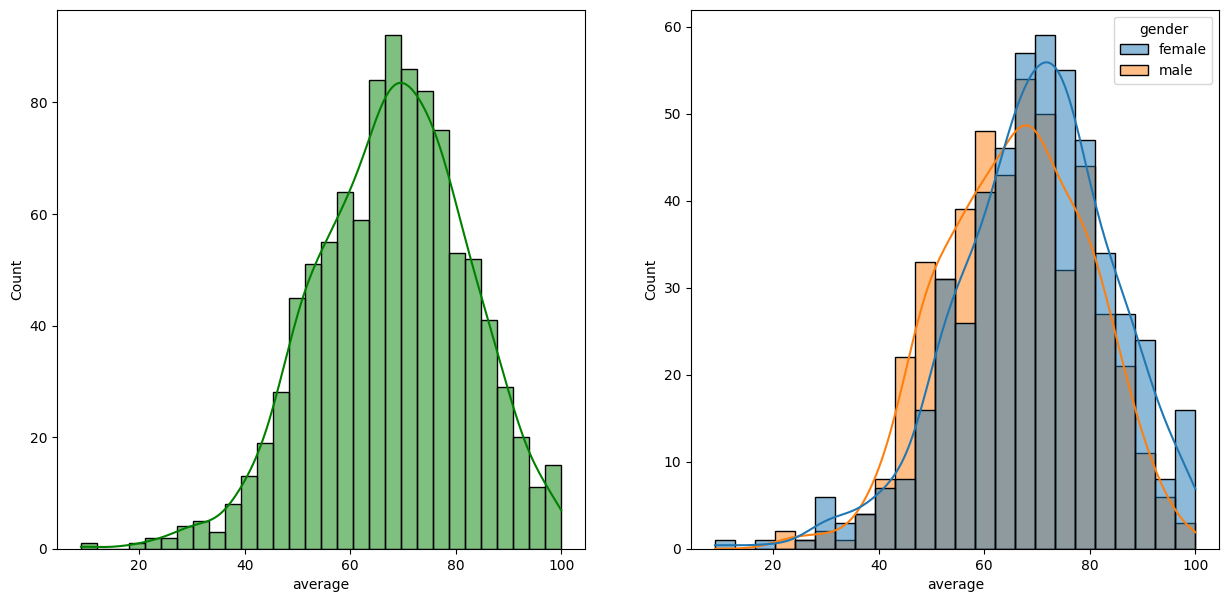

In [18]:
fig, axs = plt.subplots(1, 2, figsize = (15, 7))
plt.subplot(121)
sns.histplot(data = df, x = 'average', bins = 30, kde = True, color = 'g')
plt.subplot(122)
sns.histplot(data = df, x = 'average' , kde = True, hue = 'gender')
plt.show()

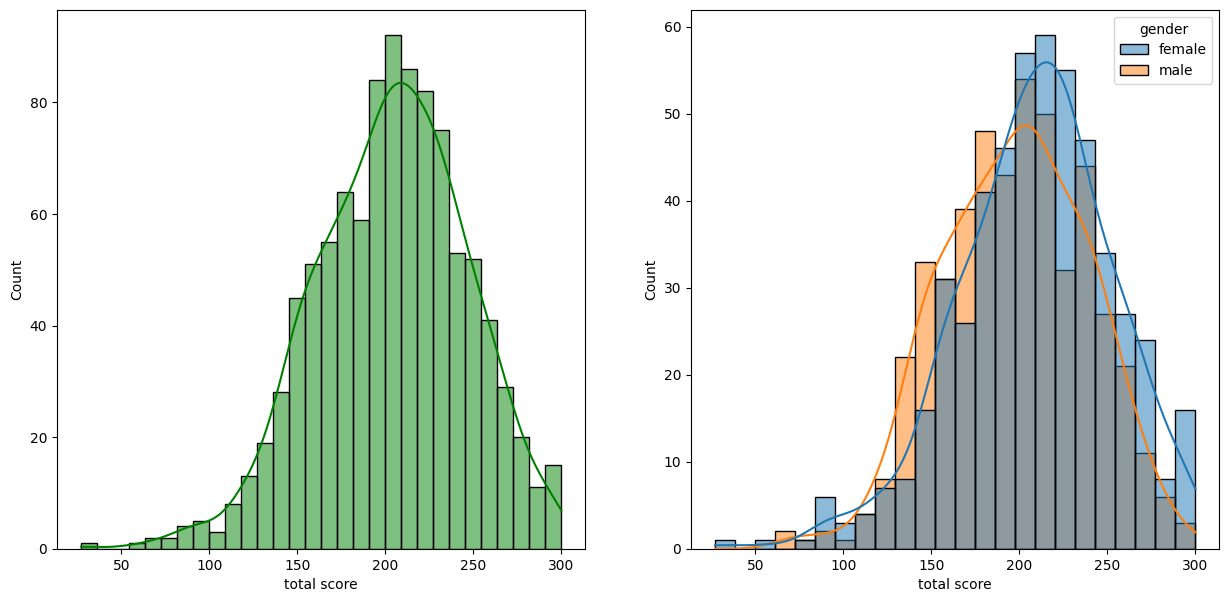

In [19]:
fig, axs = plt.subplots(1, 2, figsize = (15, 7))
plt.subplot(121)
sns.histplot(data = df, x = 'total score', bins = 30, kde = True, color = 'g')
plt.subplot(122)
sns.histplot(data = df, x = 'total score', kde = True, hue = 'gender')
plt.show()


#####  Insights
- Female students tend to perform well then male students.

<Axes: xlabel='average', ylabel='Count'>

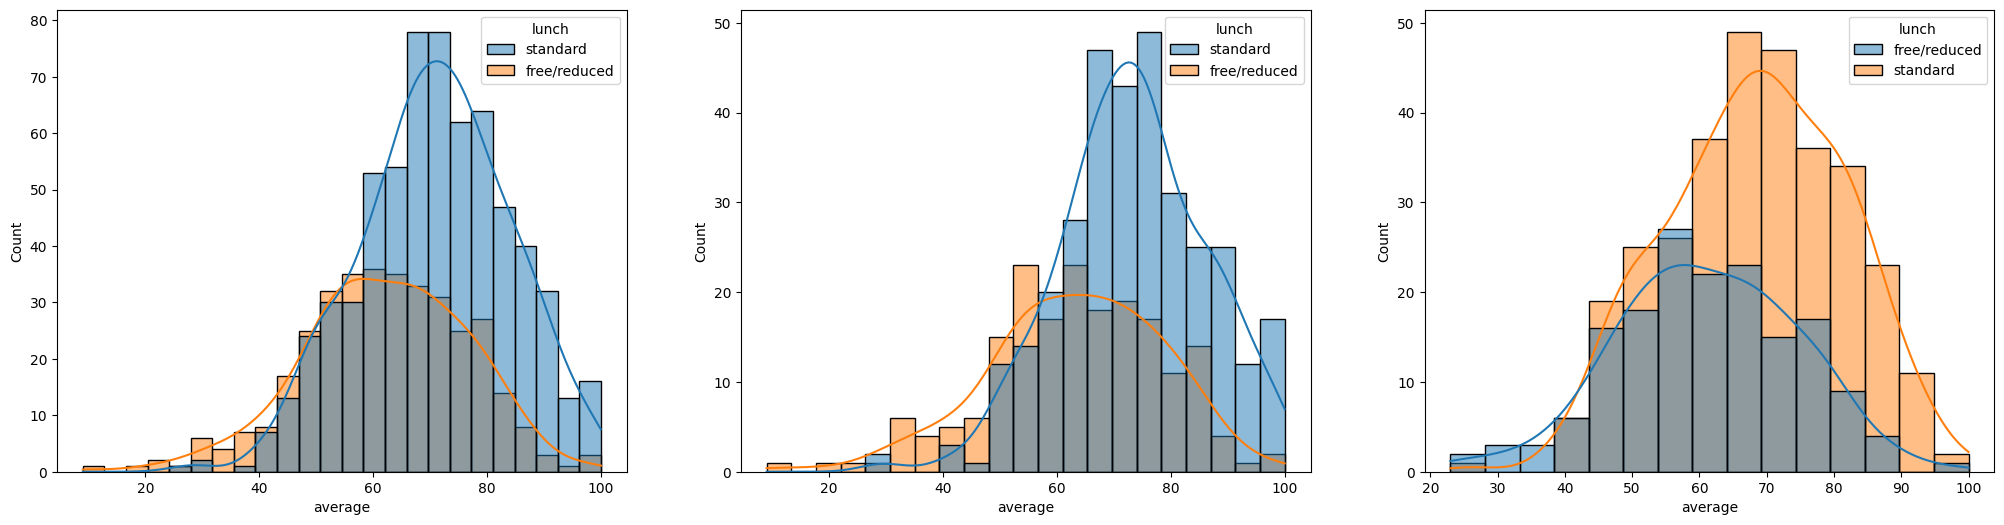

In [23]:
plt.subplots(1, 3, figsize = (25, 6))
plt.subplot(131)
sns.histplot(data = df, x = 'average', kde = True, hue = 'lunch')
plt.subplot(132)
sns.histplot(data = df[df['gender'] == 'female'], x = 'average', kde = True, hue = 'lunch')
plt.subplot(133)
sns.histplot(data = df[df['gender'] == 'male'], x = 'average', kde = True, hue = 'lunch')

#### Insights
- Standard lunch helps perform well in exams be it a male or a female

<Axes: xlabel='average', ylabel='Count'>

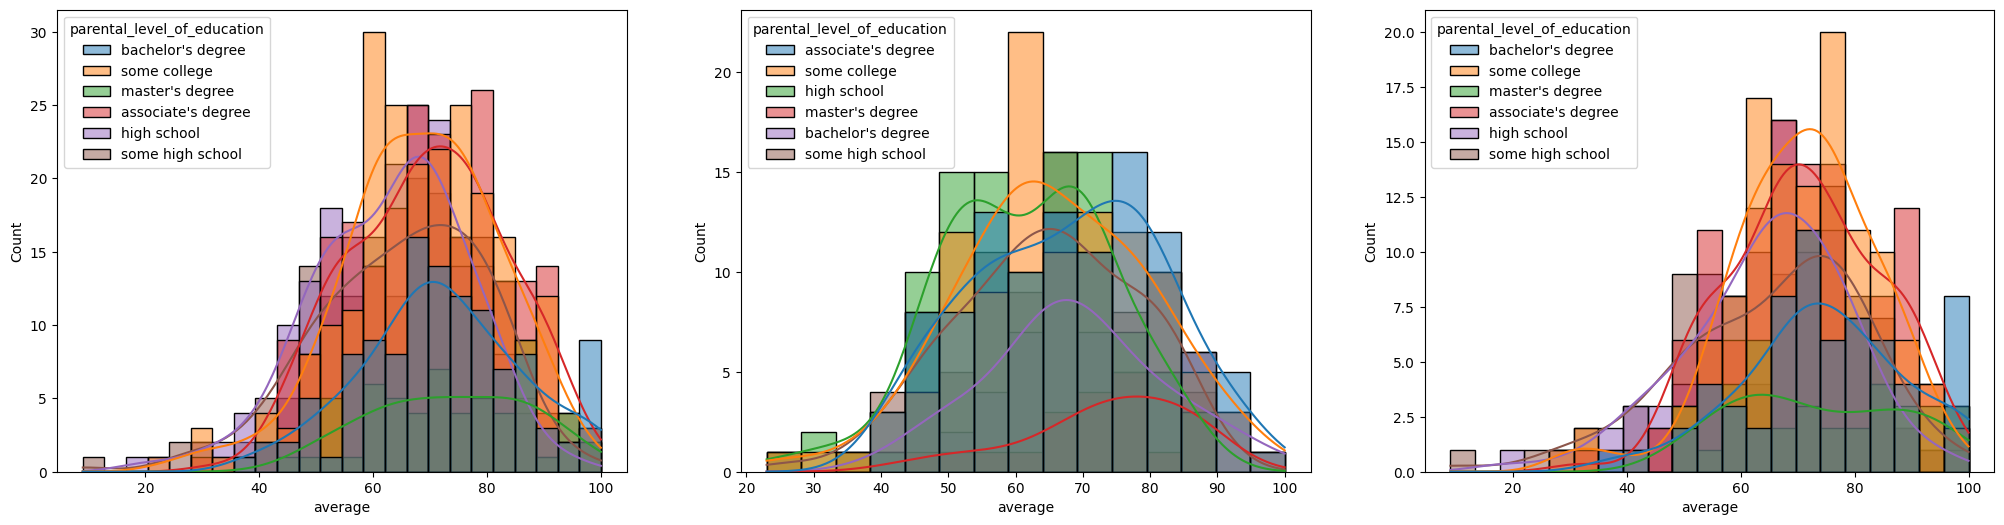

In [26]:
plt.subplots(1, 3, figsize = (25, 6))
plt.subplot(131)
sns.histplot(data = df, x = 'average', kde = True, hue = 'parental_level_of_education')
plt.subplot(132)
sns.histplot(data = df[df['gender'] == 'male'], x = 'average', kde = True, hue = 'parental_level_of_education')
plt.subplot(133)
sns.histplot(data = df[df['gender'] == 'female'], x = 'average', kde = True, hue = 'parental_level_of_education')

#### Insights
- In general, parents education dont help student perform well in exam

<Axes: xlabel='average', ylabel='Count'>

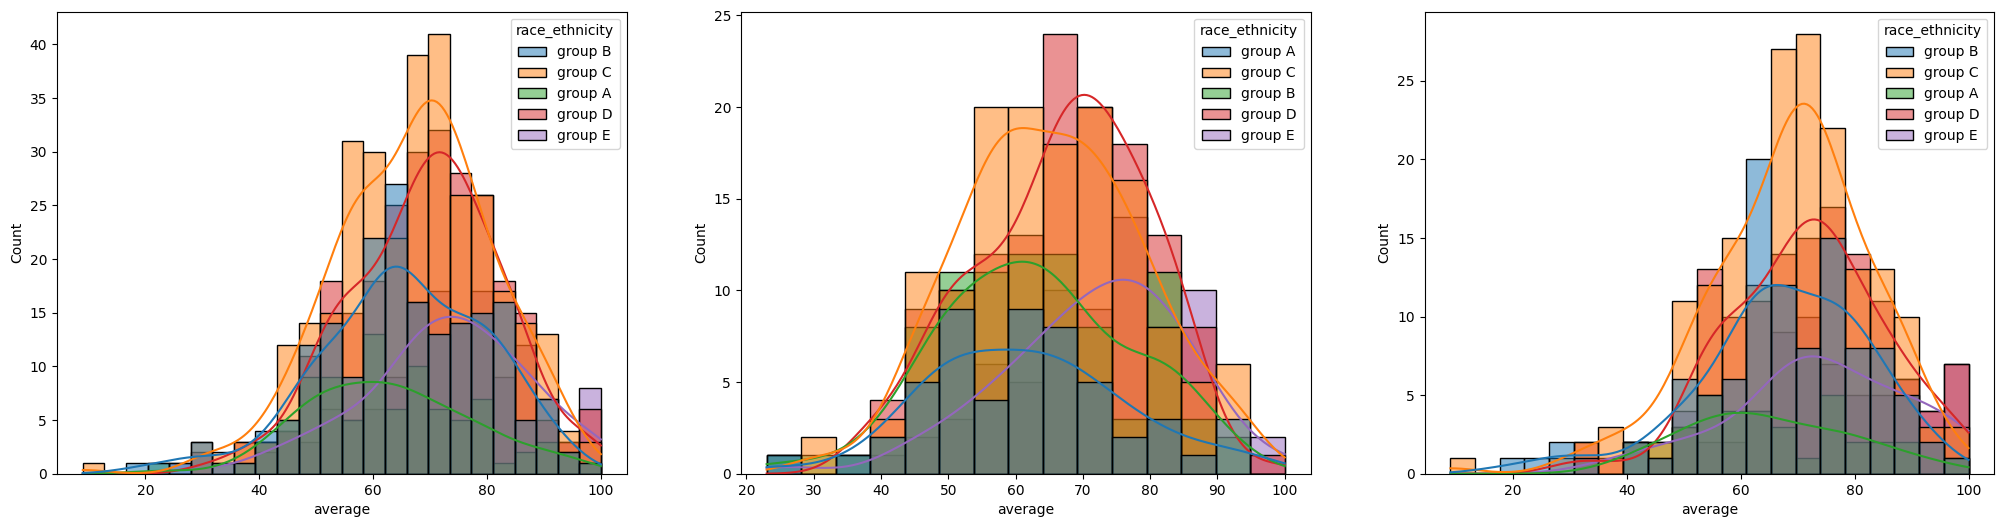

In [27]:
plt.subplots(1, 3, figsize = (25, 6))
plt.subplot(131)
sns.histplot(data = df, x = 'average', kde = True, hue = 'race_ethnicity')
plt.subplot(132)
sns.histplot(data = df[df['gender'] == 'male'], x = 'average', kde = True, hue = 'race_ethnicity')
plt.subplot(133)
sns.histplot(data = df[df['gender'] == 'female'], x = 'average', kde = True, hue = 'race_ethnicity')

#### Insights 
- Students of group C and D tend to perform well in exams
- Students of group A tend to perform poorly in exams irrespective of whether they are male or female

<Axes: title={'center': 'WRITING SCORE'}, ylabel='writing_score'>

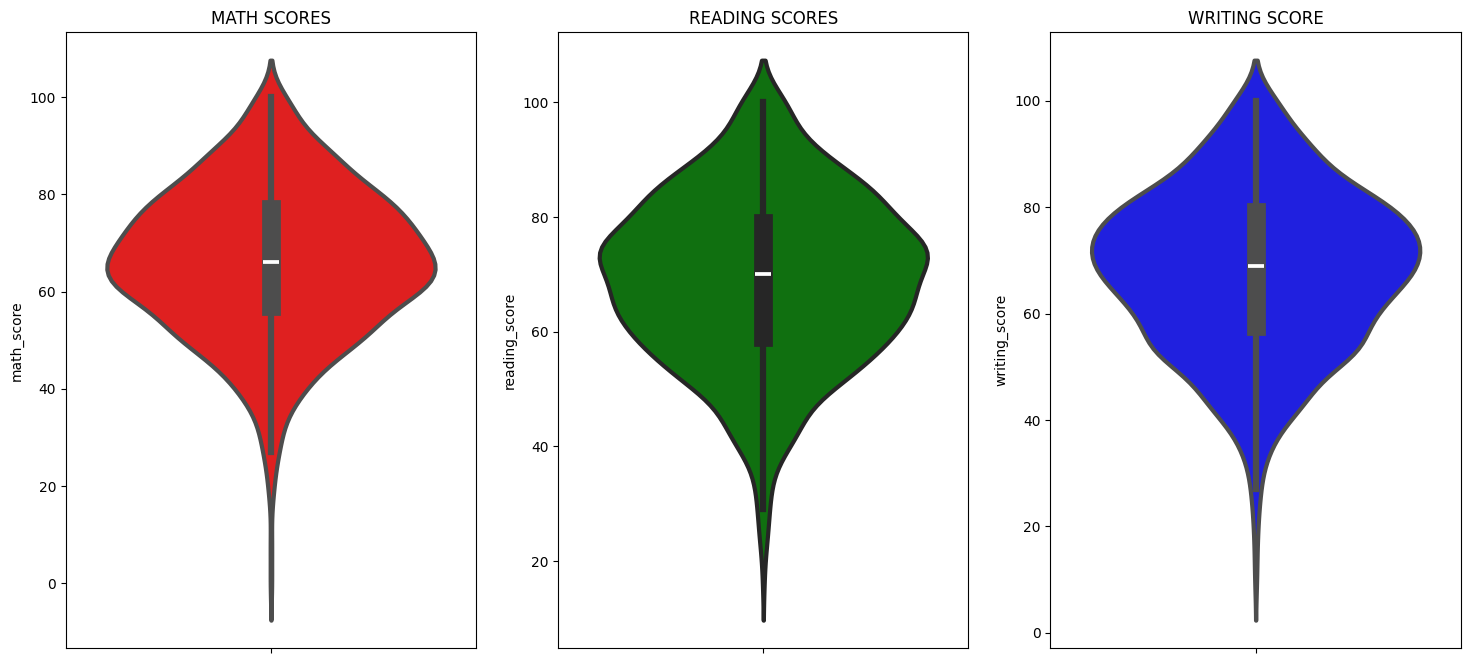

In [29]:
plt.figure(figsize = (18, 8))
plt.subplot(1, 3, 1)
plt.title('MATH SCORES')
sns.violinplot(y = 'math_score', data = df, color = 'red', linewidth = 3)
plt.subplot(1, 3, 2)
plt.title('READING SCORES')
sns.violinplot(y = 'reading_score', data = df, color = 'green', linewidth = 3)
plt.subplot(1, 3, 3)
plt.title('WRITING SCORE')
sns.violinplot(y = 'writing_score', data = df, color = 'blue', linewidth = 3 )

#### Insights
- Students performed comparatively lower in mathematics,
while reading and writing scores are higher and similarly distributed.
Most students scored between 60 and 80 in all subjects.

#### 4.3 Multivariate analysis using pieplot

(np.float64(-1.25), np.float64(1.25), np.float64(-1.25), np.float64(1.25))

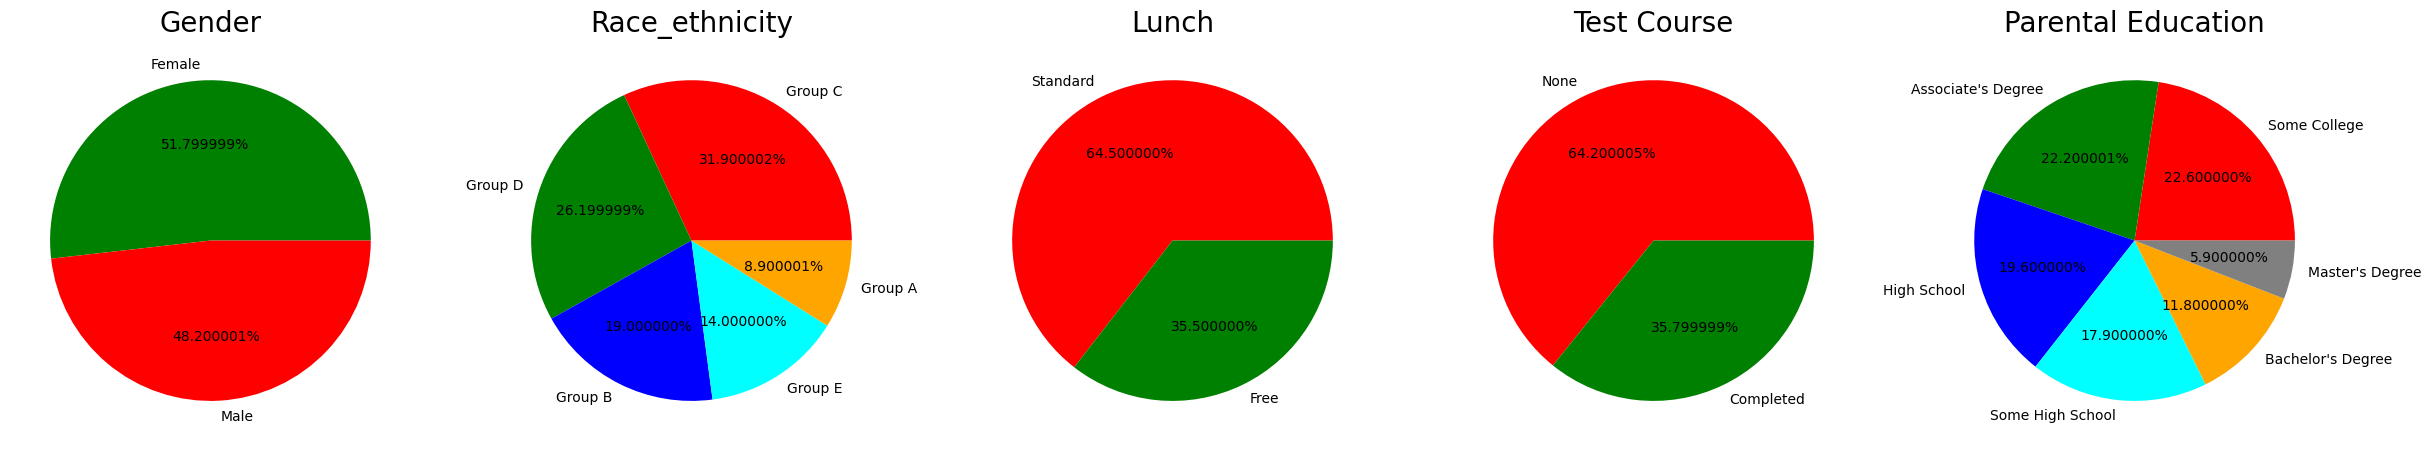

In [37]:
plt.rcParams['figure.figsize'] = (30, 12)

plt.subplot(1, 5, 1)
size = df['gender'].value_counts()
labels = 'Female', 'Male'
color = ['green', 'red']
plt.pie(size, colors = color, labels = labels, autopct='%2f%%')
plt.title('Gender', fontsize = 20)
plt.axis('off')

plt.subplot(1, 5, 2)
size = df['race_ethnicity'].value_counts()
labels = 'Group C', 'Group D','Group B','Group E','Group A'
color = ['red', 'green', 'blue', 'cyan','orange']
plt.pie(size, colors = color, labels = labels, autopct = '%2f%%')
plt.title('Race_ethnicity', fontsize = 20)
plt.axis('off')

plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()
labels = 'Standard', 'Free'
colors = ['blue', 'green']
plt.pie(size, colors = color, labels = labels, autopct = '%2f%%')
plt.title('Lunch', fontsize = 20)
plt.axis('off')

plt.subplot(1, 5, 4)
size = df['test_preparation_course'].value_counts()
labels = 'None', 'Completed'
color = ['red','green']
plt.pie(size, colors = color,labels = labels,autopct = '%2f%%')
plt.title('Test Course', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 5)
size = df['parental_level_of_education'].value_counts()
labels = 'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red', 'green', 'blue', 'cyan','orange','grey']
plt.pie(size, colors = color,labels = labels,autopct = '%2f%%')
plt.title('Parental Education', fontsize = 20)
plt.axis('off')

#####  Insights
- Number of Male and Female students is almost equal
- Number of students are greatest in Group C
- Number of students who have standard lunch are more
- Number of students who have not enrolled in any test preparation course is greater
- Number of students whose parental education is "Some College" is greater followed closely by "Associate's Degree"

#### 4.4 Feature Wise Visualization
#### 4.4.1 GENDER COLUMN
- How is distribution of Gender ?
- Does gender have any impact on student's performance ?

#### UNIVARIATE ANALYSIS ( How is distribution of Gender ? )

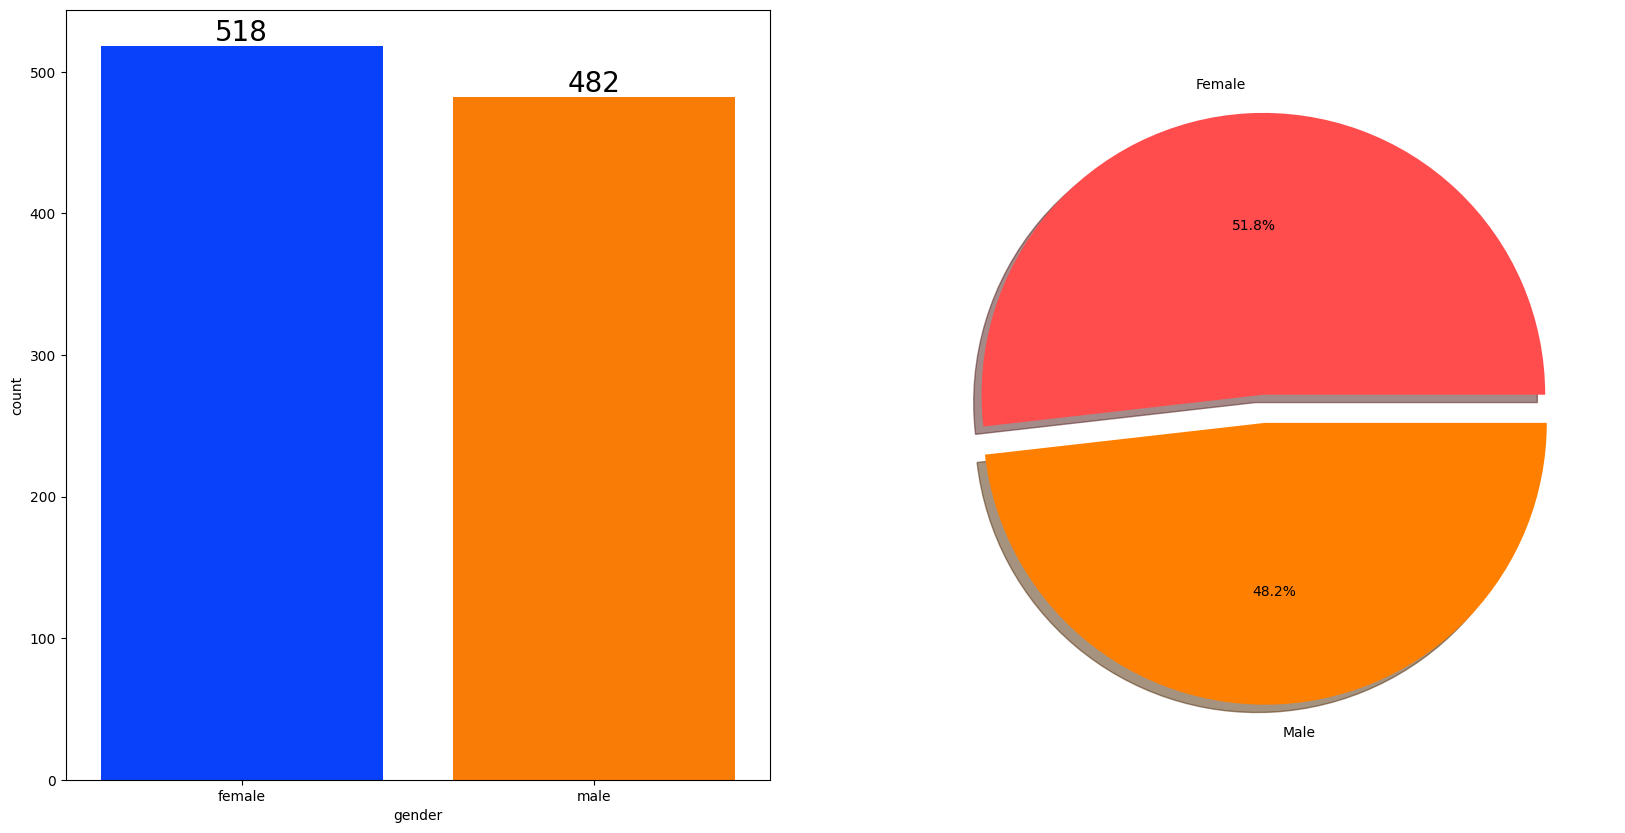

In [41]:
f, ax = plt.subplots(1, 2, figsize = (20, 10)) #ax Stores subplot axes.
sns.countplot(x = df['gender'], data = df, palette = 'bright', ax = ax[0], saturation = 0.95)
for container in ax[0].containers: #Each bar group is stored as container.
    ax[0].bar_label(container, color = 'black', size = 20)
    
ax[1].pie(df['gender'].value_counts(), labels = ['Female', 'Male'], explode = [0, 0.1], autopct = '%1.1f%%', colors=['#ff4d4d','#ff8000'], shadow = True)
plt.show()

#### Insights 
- Gender has balanced data with female students  518 (51.8%) and male students  482 (48.2%) 

#### BIVARIATE ANALYSIS ( Is gender has any impact on student's performance ? ) 

In [43]:
gender_group = df.groupby('gender').mean(numeric_only = True)
gender_group

,math_score,reading_score,writing_score,total score,average
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


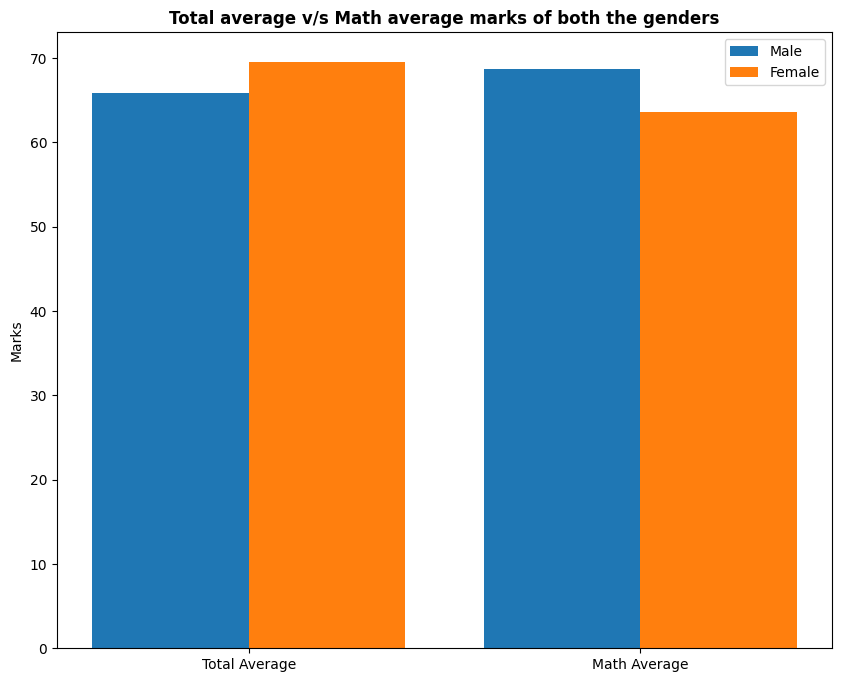

In [44]:
plt.figure(figsize = (10, 8))
X = ['Total Average', 'Math Average']

female_scores = [gender_group.loc['female', 'average'], gender_group.loc['female', 'math_score']]
male_scores = [gender_group.loc['male', 'average'], gender_group.loc['male','math_score']]

X_axis = np.arange(len(X)) #Create X-axis Positions

plt.bar(X_axis - 0.2, male_scores, 0.4, label = 'Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label = 'Female')
plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total average v/s Math average marks of both the genders", fontweight='bold')
plt.legend()
plt.show()

#### Insights 
- On an average females have a better overall score than men.
- whereas males have scored higher in Maths.

#### 4.4.2 RACE/EHNICITY COLUMN
- How is Group wise distribution ?
- Is Race/Ehnicity has any impact on student's performance ?

#### UNIVARIATE ANALYSIS ( How is Group wise distribution ?)

In [47]:
df['race_ethnicity'].value_counts()

race_ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

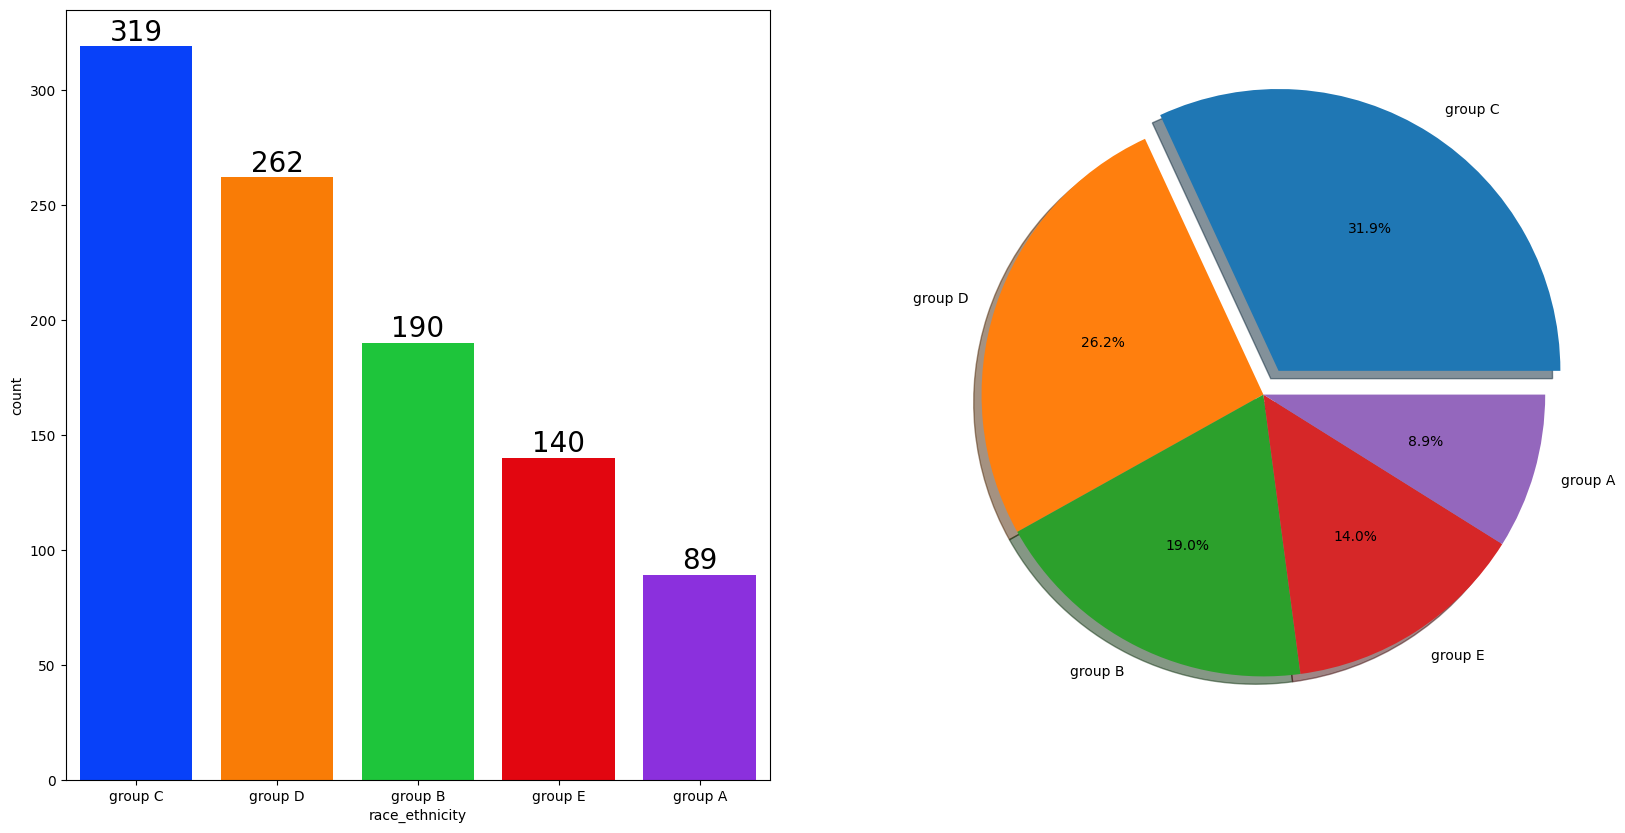

In [ ]:
order = df['race_ethnicity'].value_counts().index

f, ax = plt.subplots(1, 2, figsize=(20,10))

sns.countplot(
    x='race_ethnicity',
    data=df,
    order=order,
    palette='bright',
    ax=ax[0],
    saturation=0.95
)

for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=20)

ax[1].pie(
    df['race_ethnicity'].value_counts(),
    labels=order,
    explode=[0.1,0,0,0,0],
    shadow=True,
    autopct="%1.1f%%"
)

plt.show()

#### Insights 
- Most of the students belong from group C /group D.
- Lowest number of students belong to groupA.

#### BIVARIATE ANALYSIS ( Does Race_Ehnicity have any impact on student's performance ? )

In [56]:
race_group = df.groupby('race_ethnicity')
race_group

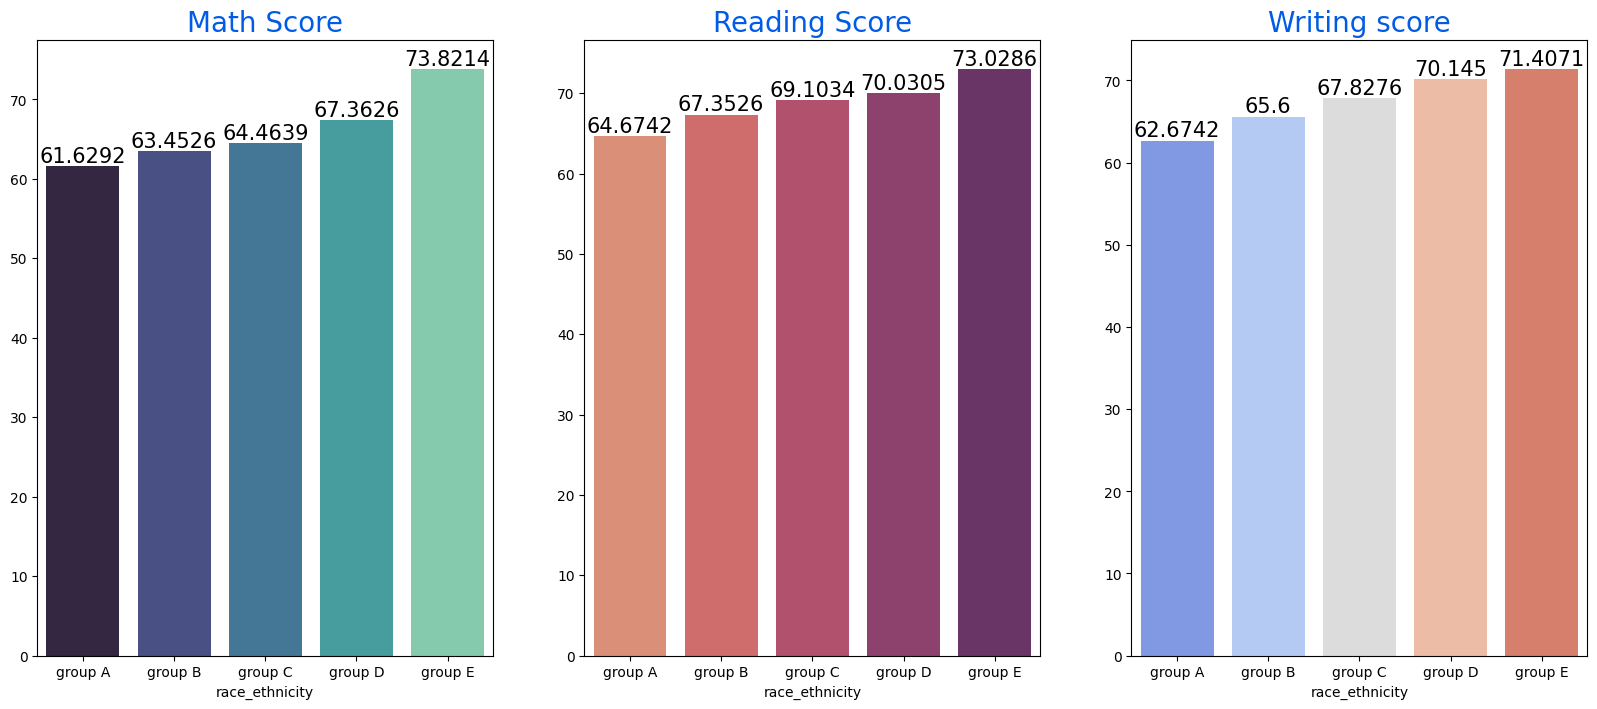

In [58]:
f, ax = plt.subplots(1, 3, figsize = (20, 8))
sns.barplot(x = race_group['math_score'].mean().index, y = race_group['math_score'].mean().values, palette = 'mako', ax = ax[0])
ax[0].set_title('Math Score', color = '#005ce6',size = 20)
for container in ax[0].containers:
    ax[0].bar_label(container, color = 'black', size = 15)

sns.barplot(x = race_group['reading_score'].mean().index, y = race_group['reading_score'].mean().values, palette = 'flare', ax = ax[1])
ax[1].set_title('Reading Score', color='#005ce6',size=20)
for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)

sns.barplot(x=race_group['writing_score'].mean().index,y=race_group['writing_score'].mean().values,palette = 'coolwarm',ax=ax[2])
ax[2].set_title('Writing score',color='#005ce6',size=20)
for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=15)

#### Insights
- Group E students have scored the highest marks
- Group A students have scored the lowest marks. 
- Students from a lower Socioeconomic status have a lower avg in all course subjects

#### 4.4.3 PARENTAL LEVEL OF EDUCATION COLUMN
- What is educational background of student's parent ?
- Does parental education have any impact on student's performance ?

#### UNIVARIATE ANALYSIS ( What is educational background of student's parent ? )

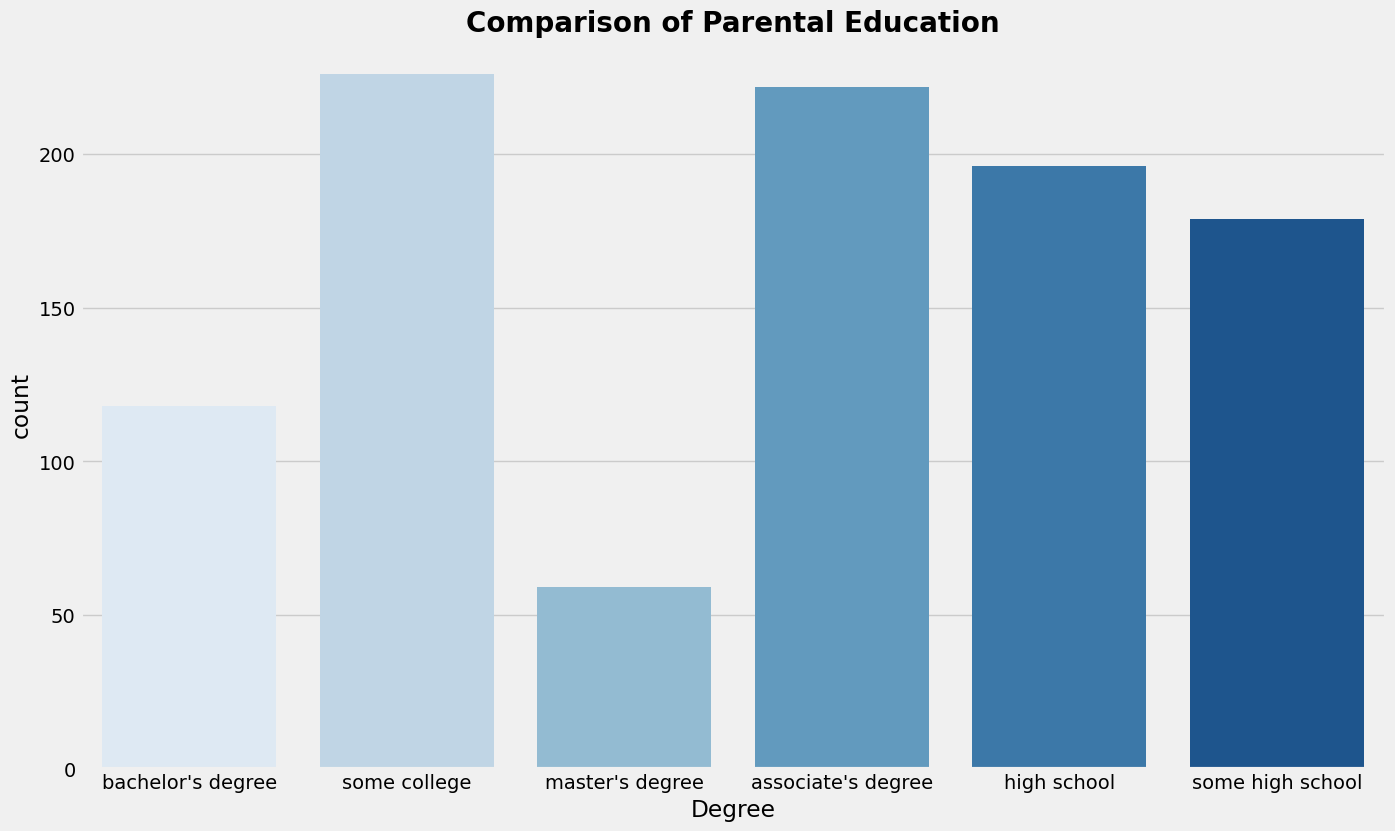

In [63]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
sns.countplot(x = df['parental_level_of_education'], palette = 'Blues')
plt.title('Comparison of Parental Education', fontweight = 'bold', fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

#### Insights 
- Largest number of parents are from some college followed closely by associates degree
- Less number of parents have a masters degree 

#### BIVARIATE ANALYSIS ( Does parental education have any impact on student's performance ? )

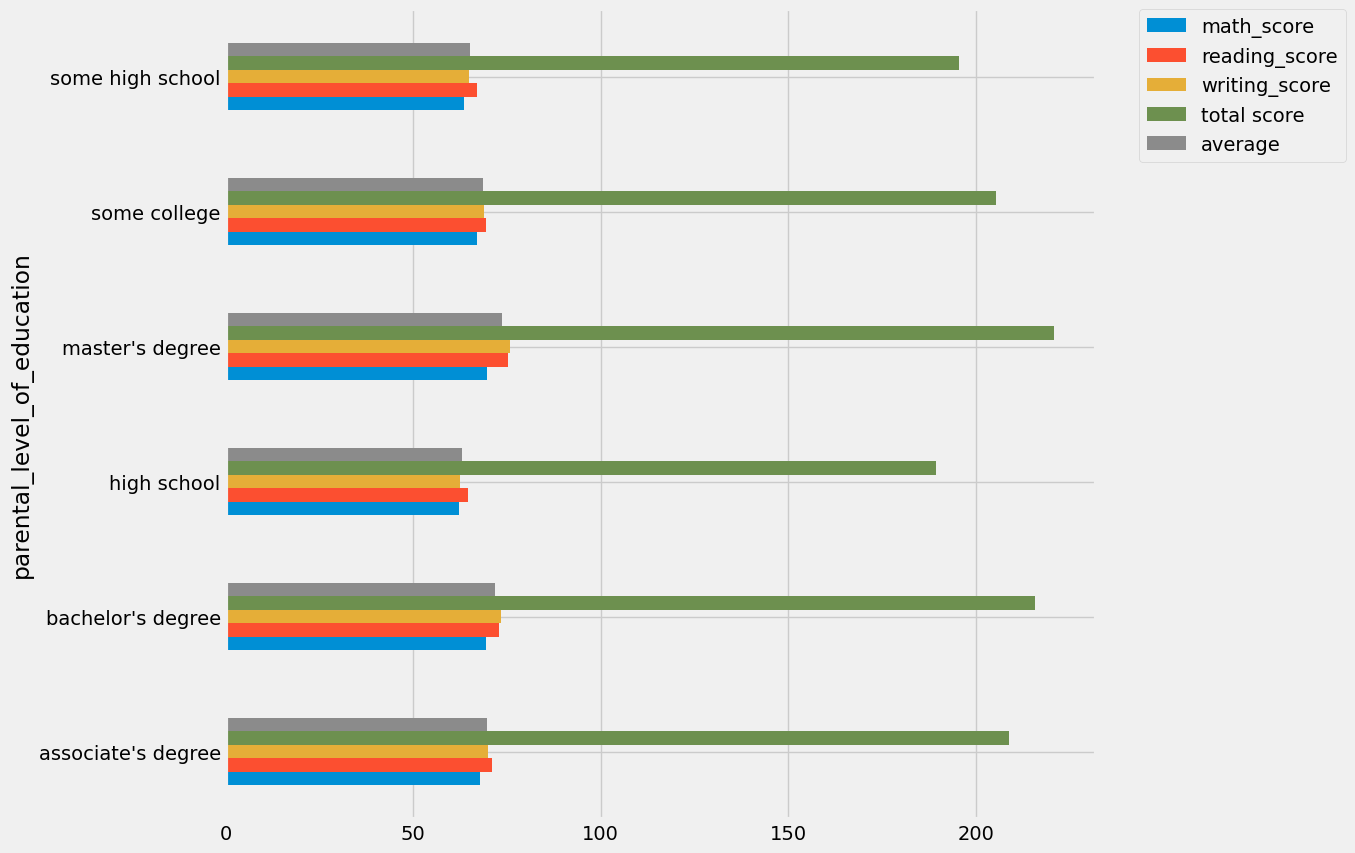

In [65]:
df.groupby('parental_level_of_education').mean(numeric_only=True).plot(kind = 'barh', figsize=(10, 10))
plt.legend(bbox_to_anchor = (1.05, 1),
           loc = 'upper left',
           borderaxespad = 0
           )
plt.show()

#### Insights 
- The score of students whose parents have master and bachelor level education is higher than others.

#### 4.4.4 LUNCH COLUMN 
- Which type of lunch is most common amoung students ?
- What is the effect of lunch type on test results?


#### UNIVARIATE ANALYSIS ( Which type of lunch is most common amoung students ? )

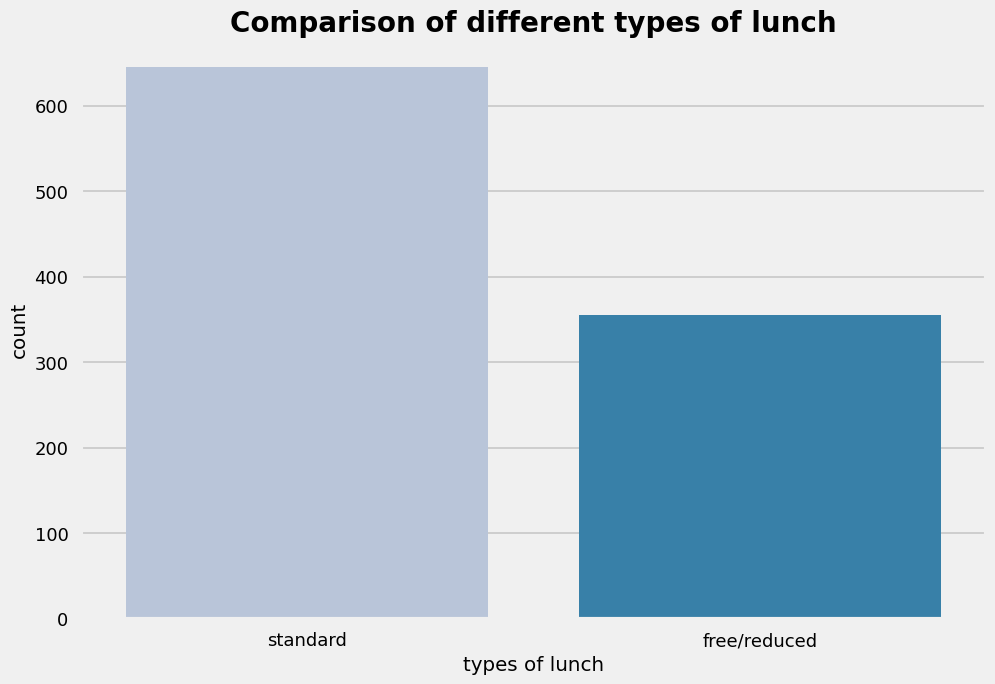

In [68]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('seaborn-v0_8-talk')
sns.countplot(x = df['lunch'], data = df, palette = 'PuBu')
plt.title('Comparison of different types of lunch', fontweight = 'bold', fontsize = 20)
plt.xlabel('types of lunch')
plt.ylabel('count')
plt.show()

#### Insights 
- Students being served Standard lunch was more than students being served free lunch

#### BIVARIATE ANALYSIS (Does lunch type intake have any impact on student's performance ? )

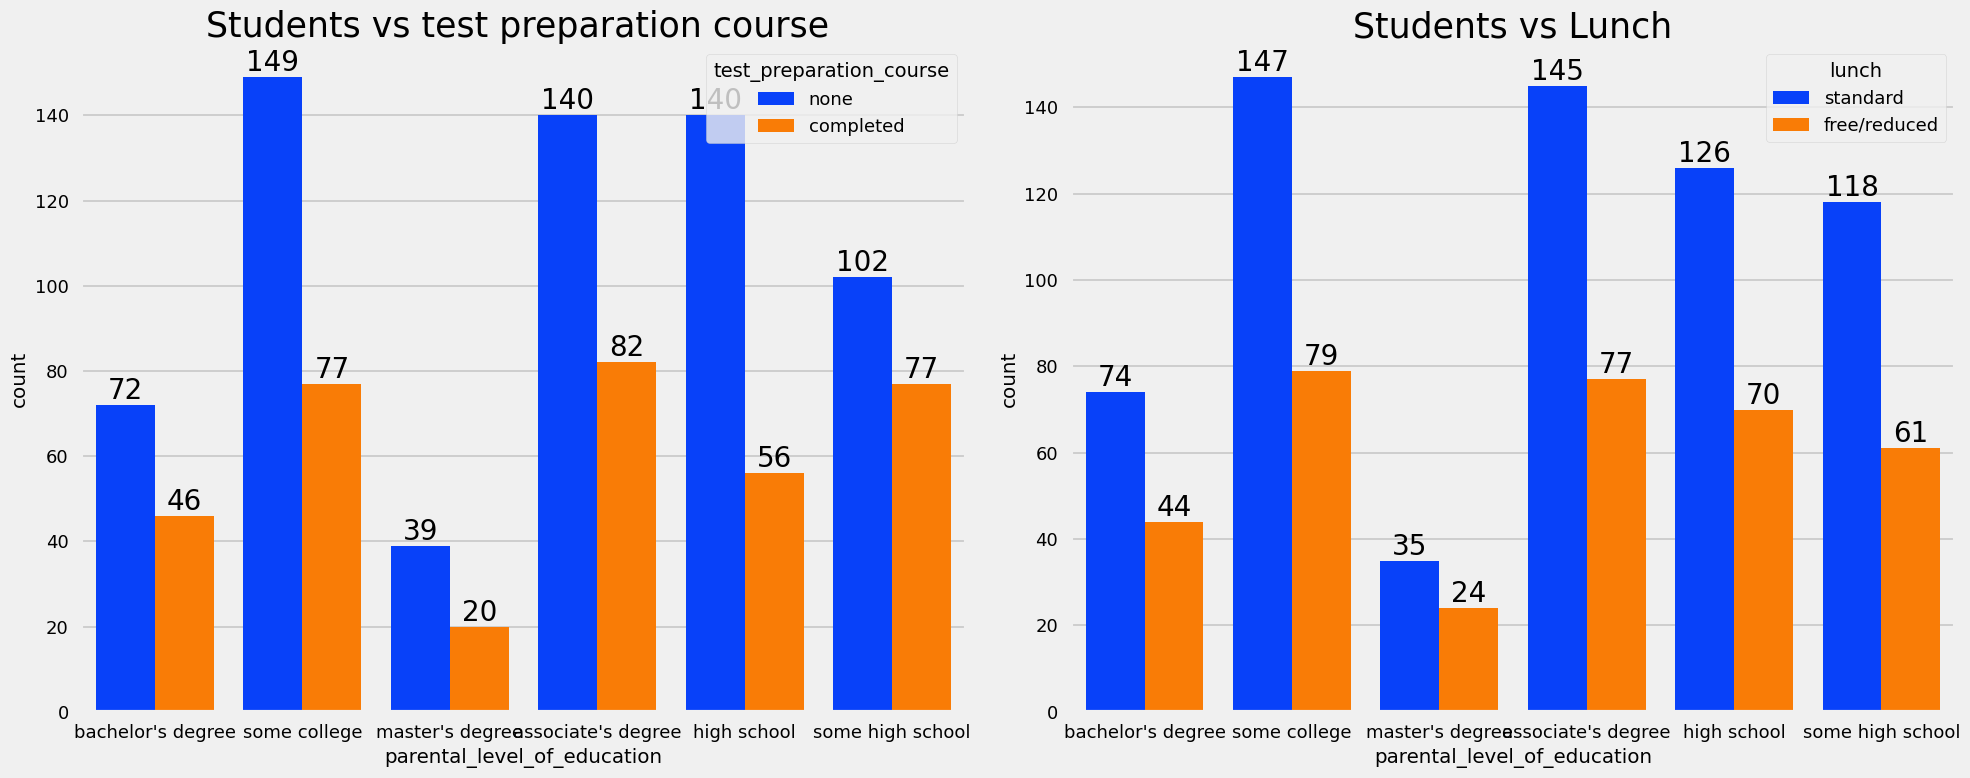

In [76]:
f, ax = plt.subplots(1, 2, figsize = (20, 8))
sns.countplot(x=df['parental_level_of_education'],data=df,palette = 'bright',hue='test_preparation_course',saturation=0.95,ax=ax[0])
ax[0].set_title('Students vs test preparation course ',color='black',size=25)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
sns.countplot(x = df['parental_level_of_education'], data = df, palette = 'bright', hue = 'lunch', ax = ax[1], saturation = 0.95)
ax[1].set_title(
    'Students vs Lunch',
    color='black',
    size=25
)
for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=20)
plt.tight_layout()
plt.show()

#### Insights 
- Students who get Standard Lunch tend to perform better than students who got free/reduced lunch

#### 4.4.5 TEST PREPARATION COURSE COLUMN 
- Which type of lunch is most common amoung students ?
- Dpes Test prepration course have any impact on student's performance ?

#### BIVARIATE ANALYSIS ( Does Test prepration course have any impact on student's performance ? )

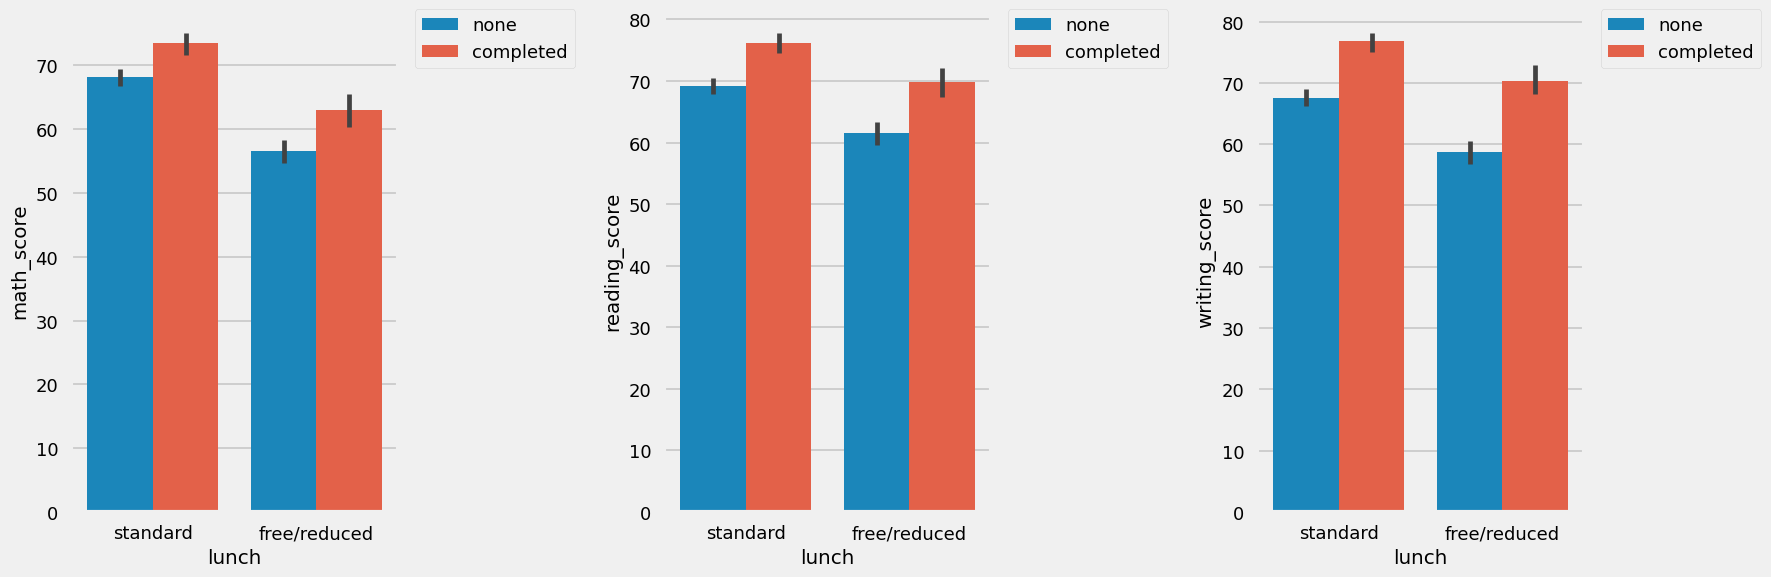

In [82]:
plt.figure(figsize=(18,6))
plt.subplot(1,3,1)
sns.barplot (x=df['lunch'], y=df['math_score'], hue=df['test_preparation_course'])
plt.legend(bbox_to_anchor = (1.05, 1), loc = 'upper left', borderaxespad = 0)
plt.subplot(1,3,2)
sns.barplot (x=df['lunch'], y=df['reading_score'], hue=df['test_preparation_course'])
plt.legend(bbox_to_anchor = (1.05, 1), loc = 'upper left', borderaxespad = 0)
plt.subplot(1,3,3)
sns.barplot (x=df['lunch'], y=df['writing_score'], hue=df['test_preparation_course'])
plt.legend(bbox_to_anchor = (1.05, 1), loc = 'upper left', borderaxespad = 0)
plt.tight_layout()
plt.show()

#### Insights  
- Students who have completed the Test Prepration Course have scores higher in all three categories than those who haven't taken the course

#### 4.4.6 CHECKING OUTLIERS

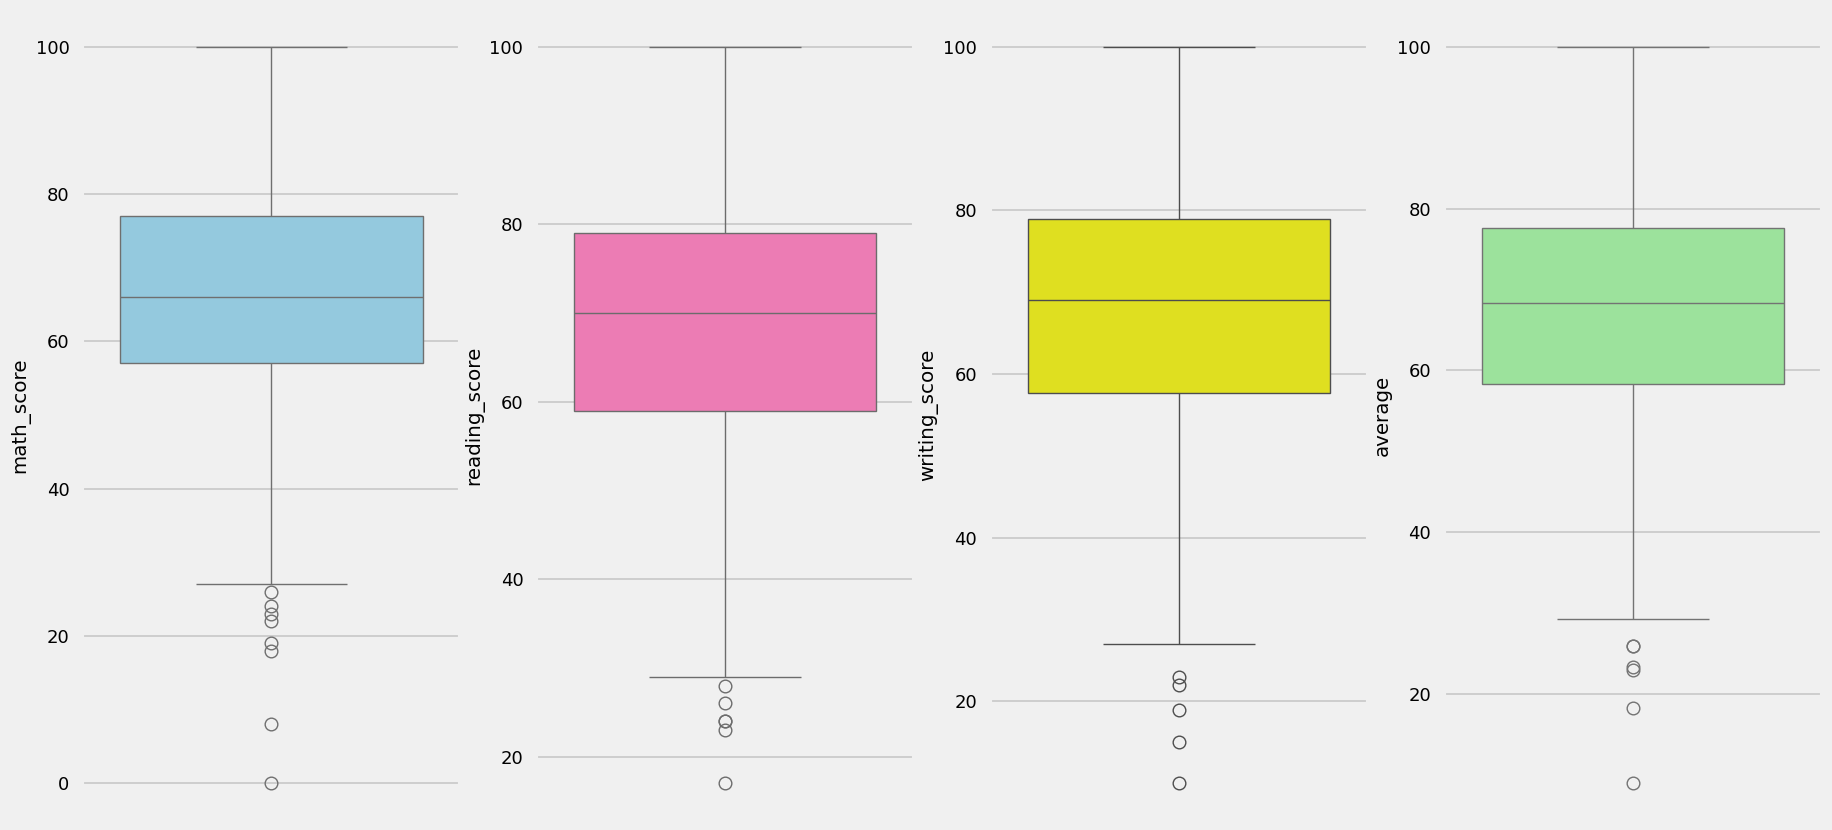

In [86]:
plt.subplots(1,4,figsize=(20,10))
plt.subplot(141)
sns.boxplot(df['math_score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading_score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing_score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['average'],color='lightgreen')
plt.show()

#### Insights
- Some low score outliers exist meaning some students get less than min marks 

#### 4.4.7 MUTIVARIATE ANALYSIS USING PAIRPLOT

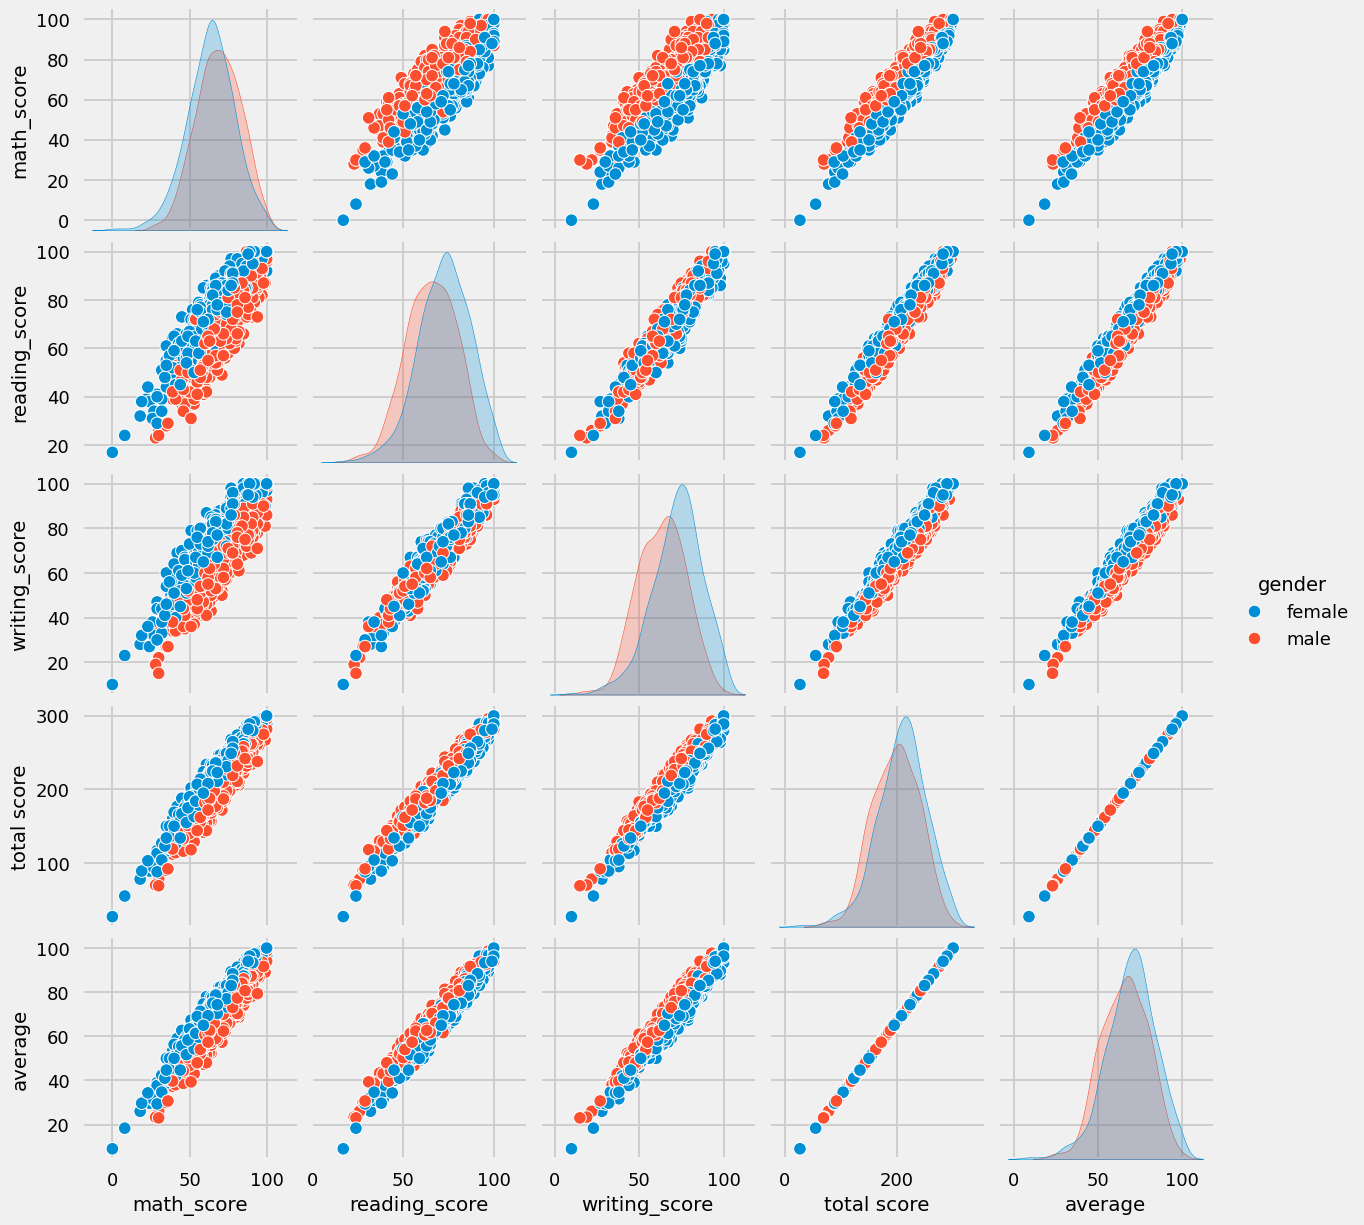

: 

In [ ]:
sns.pairplot(df,hue = 'gender')
plt.show()

#### Insights
- From the above plot it is clear that all the scores increase linearly with each other.

### 5. Conclusions
- Student's Performance is related with lunch, race, parental level education
- Females lead in pass percentage and also are top-scorers
- Student's Performance is not much related with test preparation course
- Finishing preparation course is benefitial.